In [58]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import numpy as np
import json
import sys
import os

sys.path.append('..')

print(os.getcwd())

/Users/gabrieleaccarino/Workspace/wavesim/examples/case_studies


In [40]:
path = '/Users/gabrieleaccarino/Workspace/wavesim/examples/case_studies/pna_bias_scores.csv'
scores = pd.read_csv(path)

scores['wavesim_components'] = scores['wavesim_components'].apply(
    lambda s: {k: np.array(v, dtype=np.float32) for k, v in json.loads(s).items()}
)

scores

,Earth System Model,nrmse,dssim,wavesim,wavesim_components
0,CESM2-FV2,0.939857,0.950137,0.843320,"{'magnitude': [0.96281064, 0.927211, 0.9038525..."
1,CMCC-CM2-HR4,0.890494,0.857830,0.662311,"{'magnitude': [0.7937984, 0.83416045, 0.708700..."
2,GFDL-ESM4,0.898812,0.935227,0.829319,"{'magnitude': [0.9720621, 0.9908385, 0.8250149..."


In [42]:
wavesim_components_scores = scores[['wavesim_components']]

In [43]:
wavesim_components_scores

,wavesim_components
0,"{'magnitude': [0.96281064, 0.927211, 0.9038525..."
1,"{'magnitude': [0.7937984, 0.83416045, 0.708700..."
2,"{'magnitude': [0.9720621, 0.9908385, 0.8250149..."


# Create the Radar Plot

In [55]:
wavesim_components_scores['wavesim_components'][0]['magnitude']

array([0.96281064, 0.927211  , 0.9038525 ], dtype=float32)

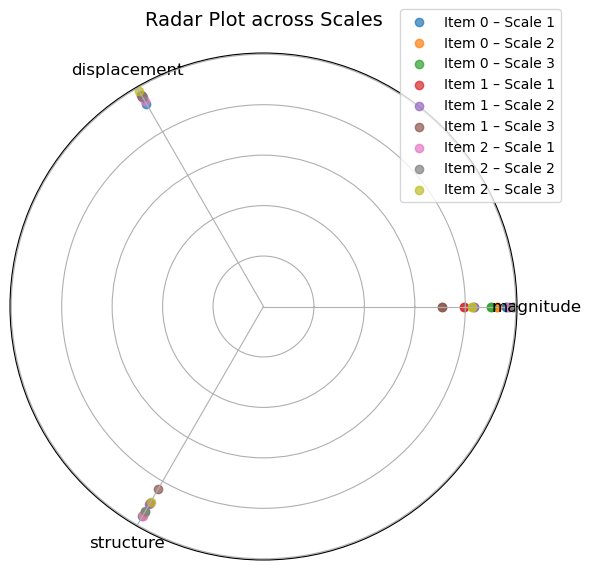

In [65]:
components = ['magnitude', 'displacement', 'structure']
num_axes = len(components)
num_scales = 3

# Compute angle of each axis
angles = np.linspace(0, 2 * np.pi, num_axes, endpoint=False).tolist()
angles += angles[:1]  # complete the loop

fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))

for i, comp_dict in enumerate(wavesim_components_scores['wavesim_components']):
    for scale_idx in range(num_scales):
        values = [comp_dict[c][scale_idx] for c in components]
        values += values[:1]  # repeat first value to close polygon
        ax.scatter(angles, values, label=f'Item {i} – Scale {scale_idx+1}', alpha=0.7)
        #ax.fill(angles, values, alpha=0.1)

# Add labels and styling
ax.set_xticks(angles[:-1])
ax.set_xticklabels(components, fontsize=12)
ax.set_yticklabels([])
ax.set_title("Radar Plot across Scales", size=14, pad=20)
ax.legend(bbox_to_anchor=(1.1, 1.1))

plt.tight_layout()
plt.show()

In [74]:
scores['wavesim_components'][1]

{'magnitude': array([0.7937984 , 0.83416045, 0.7087008 ], dtype=float32),
 'displacement': array([0.9612703, 0.9679027, 0.9639548], dtype=float32),
 'structure': array([0.89812636, 0.9060898 , 0.8373445 ], dtype=float32)}

0 0 0.8931382
0 0 0.96281064
0 0 0.9282112
0 1 0.96085685
0 1 0.927211
0 1 0.96845853
0 2 0.9524026
0 2 0.9038525
0 2 0.96505743
1 0 0.9384253
1 0 0.7937984
1 0 0.9612703
1 1 0.89812636
1 1 0.83416045
1 1 0.9679027
1 2 0.9060898
1 2 0.7087008
1 2 0.9639548
2 0 0.8373445
2 0 0.9720621
2 0 0.9403698
2 1 0.9576921
2 1 0.9908385
2 1 0.95690405
2 2 0.9355921
2 2 0.8250149
2 2 0.98792505


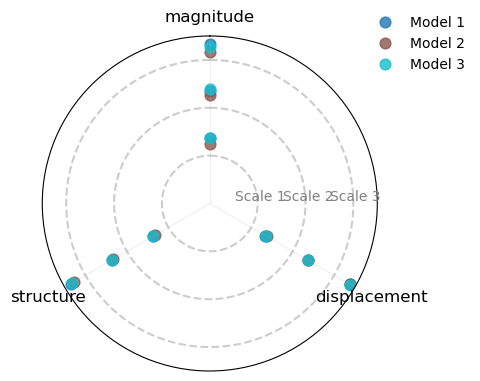

In [76]:
components = ['magnitude', 'displacement', 'structure']
num_axes = len(components)
num_scales = 3

# Set up the polar coordinates (angles)
angles = np.linspace(0, 2 * np.pi, num_axes, endpoint=False).tolist()
angles += angles[:1]

# Colors for model evaluations (rows)
colors = cm.tab10(np.linspace(0, 1, num_axes))

fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)   # Start at top
ax.set_theta_direction(-1)       # Clockwise

# --- Draw concentric circles (one per scale) ---
for scale_idx in range(num_scales):
    radius = scale_idx + 1  # radii: 1, 2, 3
    circle = np.linspace(0, 2*np.pi, 300)
    ax.plot(circle, np.full_like(circle, radius), ls='--', color='gray', alpha=0.4)
    ax.text(np.pi/2, radius + 0.05, f"Scale {scale_idx+1}", ha='center', va='bottom', fontsize=10, color='gray')

# --- Plot points ---
for model_idx, comp_dict in enumerate(wavesim_components_scores['wavesim_components']):
    for scale_idx in range(num_scales):
        base_radius = scale_idx + 1
        for comp_idx, comp in enumerate(components):
            print(model_idx, scale_idx, value)
            value = comp_dict[comp][scale_idx]
            # Value in [0,1] → map to ring [base_radius-0.4, base_radius+0.4]
            r = base_radius - 0.4 + 0.8 * value
            theta = angles[comp_idx]
            ax.scatter(theta, r, color=colors[model_idx], s=60, alpha=0.8,
                       label=f"Model {model_idx+1}" if scale_idx == 0 and comp_idx == 0 else "")

# --- Styling ---
ax.set_xticks(angles[:-1])
ax.set_xticklabels(components, fontsize=12)
ax.set_yticks([])  # remove radial ticks
ax.set_ylim(0, num_scales + 0.5)
#ax.set_title("WaveSim Components by Scale and Model", size=15, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10, frameon=False)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

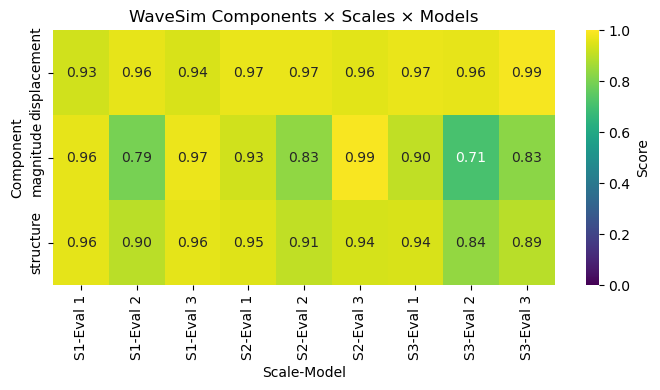

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert your dictionary to a DataFrame
records = []
for i, d in enumerate(wavesim_components_scores['wavesim_components']):
    for comp in d.keys():
        for scale_idx, v in enumerate(d[comp]):
            records.append({"Model": f"Eval {i+1}", "Component": comp, "Scale": f"S{scale_idx+1}", "Score": v})
df = pd.DataFrame(records)

plt.figure(figsize=(7,4))
sns.heatmap(df.pivot_table(index="Component", columns=["Scale","Model"], values="Score"),
            cmap="viridis", vmin=0, vmax=1, annot=True, fmt=".2f", cbar_kws={'label':'Score'})
plt.title("WaveSim Components × Scales × Models")
plt.tight_layout()
plt.show()


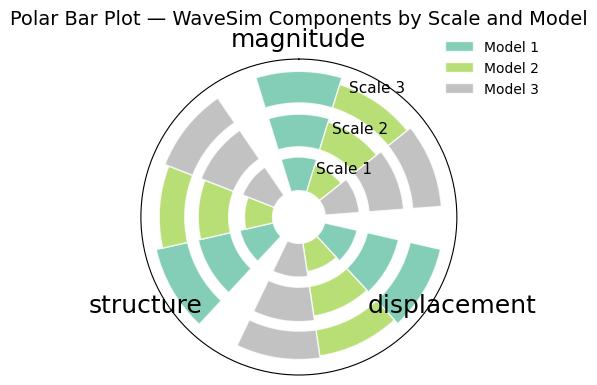

In [82]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Example data
wavesim_components_scores = {
    'wavesim_components': [
        {'magnitude': [0.96, 0.93, 0.90],
         'displacement': [0.95, 0.91, 0.89],
         'structure': [0.97, 0.94, 0.92]},
        {'magnitude': [0.79, 0.83, 0.70],
         'displacement': [0.82, 0.85, 0.75],
         'structure': [0.80, 0.87, 0.73]},
        {'magnitude': [0.97, 0.99, 0.82],
         'displacement': [0.96, 0.98, 0.81],
         'structure': [0.97, 0.99, 0.85]},
    ]
}

components = ['magnitude', 'displacement', 'structure']
num_axes = len(components)
num_scales = 3
angles = np.linspace(0, 2*np.pi, num_axes, endpoint=False)

# Colors for models
colors = cm.Set2(np.linspace(0, 1, len(wavesim_components_scores['wavesim_components'])))

fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

width = 2 * np.pi / num_axes / (len(colors) + 0.5)  # bar width
bar_spacing = width / 2

for model_idx, comp_dict in enumerate(wavesim_components_scores['wavesim_components']):
    for comp_idx, comp in enumerate(components):
        for scale_idx in range(num_scales):
            base_radius = scale_idx + 1
            score = comp_dict[comp][scale_idx]
            r0 = base_radius - 0.4
            r = r0 + 0.8 * score  # 0→inner, 1→outer
            theta = angles[comp_idx] + model_idx * width
            ax.bar(theta, height=r - r0, width=width,
                   bottom=r0, color=colors[model_idx],
                   alpha=0.8, edgecolor="white",
                   label=f"Model {model_idx+1}" if comp_idx == 0 and scale_idx == 0 else None)

# Styling
ax.set_xticks(angles)
ax.set_xticklabels(components, fontsize=18)
ax.set_yticks([1, 2, 3])
ax.set_yticklabels([f"Scale {i}" for i in range(1, num_scales+1)], fontsize=11)
ax.set_ylim(0, num_scales + 0.6)
ax.set_title("Polar Bar Plot — WaveSim Components by Scale and Model", fontsize=14, pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), frameon=False)
ax.grid(alpha=0.0)
plt.tight_layout()
plt.show()


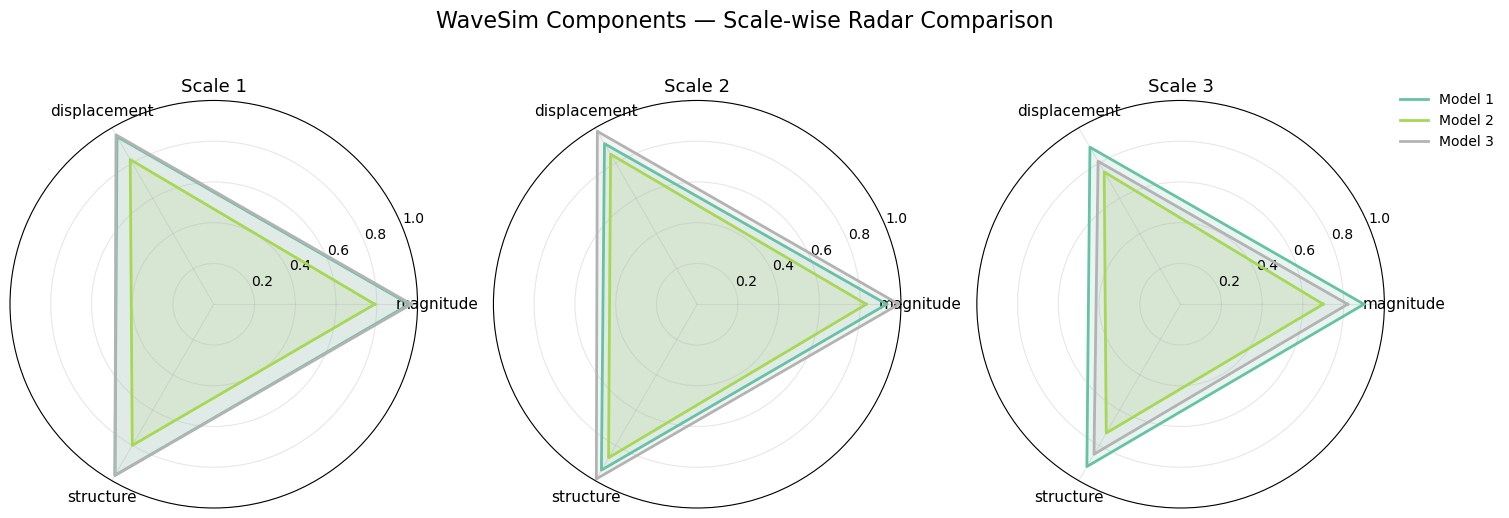

In [79]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

components = ['magnitude', 'displacement', 'structure']
num_axes = len(components)
num_scales = 3
angles = np.linspace(0, 2 * np.pi, num_axes, endpoint=False).tolist()
angles += angles[:1]

colors = cm.Set2(np.linspace(0, 1, len(wavesim_components_scores['wavesim_components'])))

fig, axes = plt.subplots(1, num_scales, figsize=(15, 5), subplot_kw=dict(polar=True))
fig.suptitle("WaveSim Components — Scale-wise Radar Comparison", fontsize=16, y=1.05)

for scale_idx, ax in enumerate(axes):
    for model_idx, comp_dict in enumerate(wavesim_components_scores['wavesim_components']):
        values = [comp_dict[c][scale_idx] for c in components]
        values += values[:1]
        ax.plot(angles, values, color=colors[model_idx], lw=2, label=f"Model {model_idx+1}")
        ax.fill(angles, values, color=colors[model_idx], alpha=0.15)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(components, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_title(f"Scale {scale_idx+1}", fontsize=13)
    ax.grid(alpha=0.3)
    if scale_idx == num_scales - 1:
        ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.05), frameon=False)

plt.tight_layout()
plt.show()
